In [48]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Normalization
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.models import Sequential
from keras.losses import MeanAbsoluteError

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
dataset_path = "/mnt/e/Deep Learning/data/auto-mpg.csv"
row_df = pd.read_csv(dataset_path, sep=',')
df = row_df.copy()
df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70
5,15.0,8,429.0,198.0,4341,10.0,70
6,14.0,8,454.0,220.0,4354,9.0,70
7,14.0,8,440.0,215.0,4312,8.5,70
8,14.0,8,455.0,225.0,4425,10.0,70
9,15.0,8,390.0,190.0,3850,8.5,70


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    396 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model-year    398 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 21.9 KB


In [17]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
393,27.0,4,140.0,86.0,2790,15.6,82
394,44.0,4,97.0,52.0,2130,24.6,82
395,32.0,4,135.0,84.0,2295,11.6,82
396,28.0,4,120.0,79.0,2625,18.6,82
397,31.0,4,119.0,82.0,2720,19.4,82


In [18]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      2
weight          0
acceleration    0
model-year      0
dtype: int64

In [19]:
df[df['horsepower'].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
32,25.0,4,98.0,NaN,2046,19.0,71
126,21.0,6,200.0,NaN,2875,17.0,74


In [24]:
df.dropna(inplace=True)

In [23]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70
...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82
394,44.0,4,97.0,52.0,2130,24.6,82
395,32.0,4,135.0,84.0,2295,11.6,82
396,28.0,4,120.0,79.0,2625,18.6,82


In [ ]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Number of samples in train data: {train_df.shape[0]}")
print(f"Number of samples in val data: {val_df.shape[0]}")

Number of samples id train data: 316
Number of samples id val data: 80


In [29]:
train_data = train_df.copy()
val_data = val_df.copy()

train_labels = train_data['mpg']
val_labels = val_data['mpg']

In [32]:
train_data.drop(columns='mpg', inplace=True)
val_data.drop(columns='mpg', inplace=True)

In [34]:
print(f"Number of samples in train data: {train_data.shape[0]}")
print(f"Number of samples in val data: {val_data.shape[0]}")

print("_" * 40)

print(f"Number of features in train data: {train_data.shape[1]}")
print(f"Number of features in val data: {val_data.shape[1]}")

Number of samples in train data: 316
Number of samples in val data: 80
________________________________________
Number of features in train data: 6
Number of features in val data: 6


In [38]:
normalizer = Normalization(axis=-1)
normalizer.adapt(np.array(train_data))

W0000 00:00:1777940740.439718   45469 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [42]:
print(f"Mean of features: {normalizer.mean.numpy()}")
print(f"Variance of features: {normalizer.variance.numpy()}")

Mean of features: [[   5.4462028  192.33228    103.63608   2958.1836      15.487975
    76.24051  ]]
Variance of features: [[2.8610299e+00 1.0617285e+04 1.4273455e+03 7.0547456e+05 7.0818806e+00
  1.3226967e+01]]


In [57]:
model = Sequential()

model.add(Input(shape=(train_data.shape[1], )))
model.add(normalizer)
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

In [58]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 6)              │            13 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,686 (18.31 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 13 (56.00 B)

In [59]:
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss=MeanAbsoluteError)

In [60]:
history = model.fit(train_data, train_labels, validation_data=(val_data, val_labels), epochs=150, batch_size=8)

Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 22.2925 - val_loss: 18.7243
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.8251 - val_loss: 10.7977
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.3355 - val_loss: 4.9538
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0464 - val_loss: 3.6971
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3921 - val_loss: 3.2181
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1048 - val_loss: 3.1740
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8997 - val_loss: 2.9129
Epoch 8/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7227 - val_loss: 2.7920
Epoch 9/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6068 - val_loss: 2.5918
Epoch 10/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5702 - val_loss: 2.5339
Epoch 11/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4414 - val_loss: 2.5631
Epoch 12/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss:

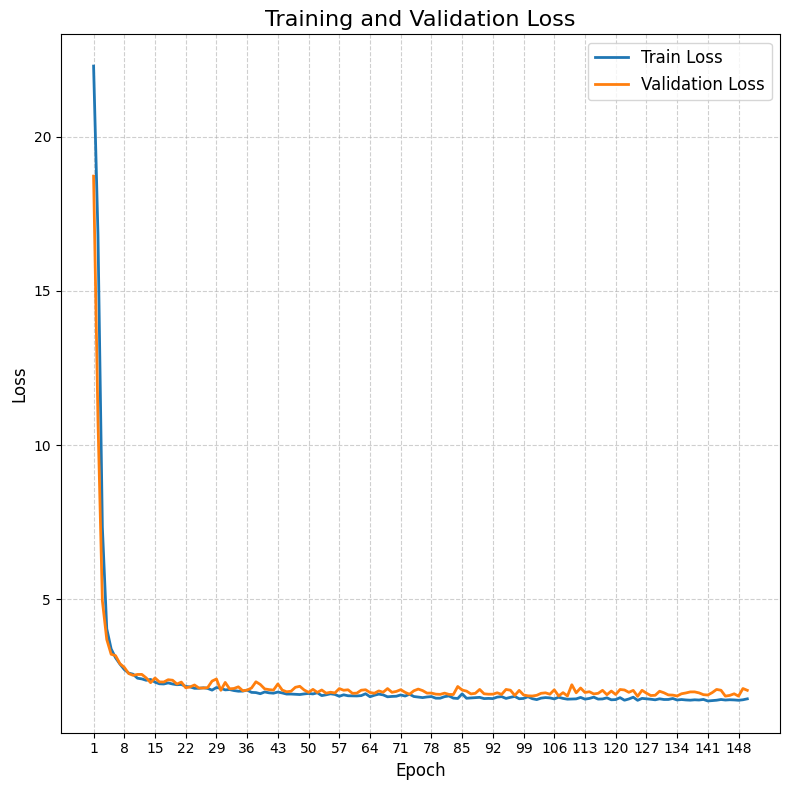

In [63]:
import numpy as np
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = np.arange(1, len(loss) + 1)

plt.figure(figsize=(8, 8))

plt.plot(epochs, loss, label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)

plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks(epochs[::7])  
plt.tight_layout()
plt.show()
